# Imports

In [1]:
import os
import sys

In [2]:
current_dir =  os.getcwd()
# replace this following line in the path your frank2d files are.
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [4]:
# frank2d
from frank2d import Frank2D
from frank2d.geometry import Geometry
from frank2d.posterior_optimization import *
from frank2d.constants import rad_to_arcsec, deg_to_rad
from frank2d.plot import Plot

# frank1d
from frank.utilities import UVDataBinner

## Functions

In [5]:
def calculate_resolution( clean_beam, current_beam):
    bmaj_as = clean_beam['bmaj']
    bmin_as = clean_beam['bmin']
    final_bmaj_as = np.sqrt(bmaj_as**2 - current_beam**2)
    final_bmin_as = np.sqrt(bmin_as**2 - current_beam**2)
    print(f"-> Final beam to convolve with: {final_bmaj_as} x {final_bmin_as} arcsec")
    final_resolution = {'bmaj': final_bmaj_as, 'bmin': final_bmin_as, 'beam_pa': clean_beam['beam_pa']}
    return final_resolution

In [6]:
def calculate_resolution2( clean_beam, current_beam):
    from radio_beam import Beam
    bmaj_clean = clean_beam['bmaj']
    bmin_clean = clean_beam['bmin']
    bpa_deg_clean = clean_beam['beam_pa']

    bmaj_current = current_beam['bmaj']
    bmin_current = current_beam['bmin']
    bpa_deg_current = current_beam['beam_pa']

    beam_orig =  Beam(major=bmaj_current*u.arcsec, minor=bmin_current*u.arcsec, pa=bpa_deg_current)
    beam_target = Beam(major=bmaj_clean*u.arcsec, minor=bmin_clean*u.arcsec, pa=bpa_deg_clean)

    beam_final = beam_target.deconvolve(beam_orig)

    #return values in a dict
    final_resolution = {'bmaj': beam_final.major.to(u.arcsec).value,
                        'bmin': beam_final.minor.to(u.arcsec).value,
                        'beam_pa': beam_final.pa.to(u.deg).value}

    return final_resolution


In [7]:
def edges(x):
    mids = (x[1:] + x[:-1]) / 2.0
    first = x[0]  - (x[1] - x[0]) / 2.0
    last  = x[-1] + (x[-1] - x[-2]) / 2.0
    return np.r_[first, mids, last]


In [8]:
def get_profile( x1, x2, f, bins, weighted = False, weights = None, fit_1d = False):
    from scipy.stats import binned_statistic
    
    if not fit_1d:
        r = np.hypot(x1, x2)
        r = r.ravel(order = 'C')
        f = f.ravel(order = 'C')
    else:
        r = x1

    if weighted:
        if weights is None:
            raise ValueError("Add weights.")
        F_W_binned, bin_edges, _ = binned_statistic(r, f*weights, 'sum', bins = bins)
        Weights_binned, bin_edges, _ = binned_statistic(r, weights, 'sum', bins = bins)

        f_1d = np.nan_to_num(F_W_binned, nan=0)
        f_1d = f_1d/Weights_binned
    else:
        f_1d, bin_edges, _ = binned_statistic(r, f, 'mean', bins = bins)
    
    r_1d = (bin_edges[:-1] + bin_edges[1:]) / 2
        
    return r_1d, f_1d

In [9]:
def create_disk_image_blob_jy_per_pixel(
    N=500,                         # Image size (N x N pixels)
    pixel_scale_arcsec=0.01,       # Pixel scale (0.01 arcsec = 10 mas)
    sigma_core=0.04,               # Gaussian core width (arcsec)
    R_rings=[0.4, 0.6, 0.8],       # Radii of the rings/blobs (arcsec)
    width_rings=[0.05, 0.02, 0.05], # Gaussian width of the rings (arcsec)
    width_blobs=[0.03, 0.03, 0.03], # Width of the localized blobs (arcsec)
    amp_core=0.1,                  # Core amplitude (Jy/pixel)
    amp_rings=[0.05, 0.04, 0.03],  # Rings amplitude (Jy/pixel)
    m_modes=[1, 0, 0],             # Asymmetry mode (1 -> blob, 0 -> ring)
    theta0=[np.pi, 0, 0],     # Blob position angle (radians)
    amp_asym=[0.9, 0, 0]           # Asymmetry/blob amplitude (fraction of amp_rings)
):
    """
    Creates a synthetic disk image directly in Jy/pixel by summing
    Gaussian and annular components in the image plane.
    """
    
    # 1. Prepare coordinate grid and radii
    
    # Pixel coordinates (in arcsec, with center at (0, 0))
    x_arcsec = (np.arange(N) - N / 2) * pixel_scale_arcsec
    y_arcsec = (np.arange(N) - N / 2) * pixel_scale_arcsec
    
    # Create the 2D grid of coordinates and radii
    X, Y = np.meshgrid(x_arcsec, y_arcsec)
    R_image = np.sqrt(X**2 + Y**2)
    Phi_image = np.arctan2(Y, X) # Polar angle of each pixel
    
    # Initialize the total image in Jy/pixel
    I_disk_jy_per_pixel = np.zeros((N, N))
    
    # 2. Add the Central Gaussian Core
    
    # 2D Gaussian Formula: I(r) = A * exp(- (r^2 / (2 * sigma^2)))
    # Note: Your original code uses exp(-2 * (pi * sigma * baseline)^2), 
    # which is the FT of a Gaussian. In the image plane, we use the standard form:
    sigma_image = sigma_core / np.sqrt(2 * np.log(2)) # Approximation FWHM -> sigma (Commented out line, original uses sigma_core directly)
    
    I_core = amp_core * np.exp(-0.5 * (R_image / sigma_core)**2)
    I_disk_jy_per_pixel += I_core
    
    # 3. Add Rings and Blobs
    
    # Iterate over the properties of each component
    for A, R, w, w_blob, m, th0, Aasym in zip(amp_rings, R_rings,
                                              width_rings, width_blobs,
                                              m_modes, theta0, amp_asym):
        
        # Symmetric Ring (Gaussian centered at radius R)
        # Formula: I(r) = A * exp(-(r - R)^2 / (2 * w^2))
        I_ring = A * np.exp(-0.5 * ((R_image - R) / w)**2)
        I_disk_jy_per_pixel += I_ring
        
        # Asymmetric Blobs (Displaced Gaussian)
        if m != 0 and Aasym > 0:
            
            # Blob center position (in arcsec)
            x0 = R * np.cos(th0)
            y0 = R * np.sin(th0)
            
            # Coordinate offset
            X_blob = X - x0
            Y_blob = Y - y0
            R_blob_sq = X_blob**2 + Y_blob**2
            
            # Blob amplitude (fraction of the ring)
            A_blob = Aasym * A
            
            # Blob Gaussian (centered at (x0, y0))
            I_blob = A_blob * np.exp(-0.5 * (R_blob_sq / w_blob**2))
            
            I_disk_jy_per_pixel += I_blob
            
    return I_disk_jy_per_pixel

# Data

In [10]:
# UVtable
dir = "../../data/uvtable/"
data_file = dir +"uvtable_SimulatedBlob.txt"

# Load data
file = np.loadtxt(data_file, unpack = True)
u, v, Re, Im, Weights = file
Vis = Re + Im*1j

In [11]:
inc = 0
pa = 0
dra = 0
ddec = 0
rout = 1

In [12]:
q_min = np.hypot(u,v).min()
q_max = np.hypot(u,v).max()
print(f"-> q_min data: {q_min}, q_max data: {q_max}")

-> q_min data: 11479.355483435862, q_max data: 8828201.715647701


In [13]:
Rmax = 3*rout
import math 
N = math.floor(5* Rmax/rad_to_arcsec * q_max)

print("N =", N)
print("Rmax =", Rmax)

N = 642
Rmax = 3


In [14]:
imsize = N

In [15]:
geom_f2d = Geometry(inc, pa, dra, ddec)

In [16]:
uvtable = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights}

In [17]:
best_N50 = {'m': -1.117860242672363, 'c': 2113.8916919178832, 'l': 56439.474897224536}
best_N100 = { 'm': -2.1944372236318923, 'c': 2760753036.139108, 'l': 45719.70197102792 }

In [18]:
best_N50_Rmax5 = {'m': -1.972719134084518, 'c': 58157011.81131077, 'l': 26595.265124130965}

In [19]:
best = best_N50

In [20]:
frank2d = Frank2D(N, Rmax)

In [21]:
start_time = time.time()
frank2d.fit(data = uvtable, kernel_params = best, rtol = 1e-10 )

end_time = time.time()
print(f"xxxxxxxxxxxxxxxxxxxxxxxxx F2D with N = {imsize} took {end_time - start_time} seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx")

===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -1.117860242672363, 'c': 2113.8916919178832, 'l': 56439.474897224536}
===>  Creating sparse linear system...
        +  Kernel = 0.12  min |  7.47 seconds
        +  Building system = 0.13  min |  7.65 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   1%|          | 279/50000 [01:15<3:43:00,  3.72 iterations/s]


            +  BiCGStab = 1.27  min |  76.38 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of s',
 'final_tol': 0.07435963551417657,
 'iterations': 279,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-10}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.46  min |  27.87 seconds
--> times building full visibility model = 0.47  min |  27.92 seconds
xxxxxxxxxxxxxxxxxxxxxxxxx F2D with N = 642 took 121.78798174858093 seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx


In [22]:
Plot_ = Plot(frank2d, geom_f2d)

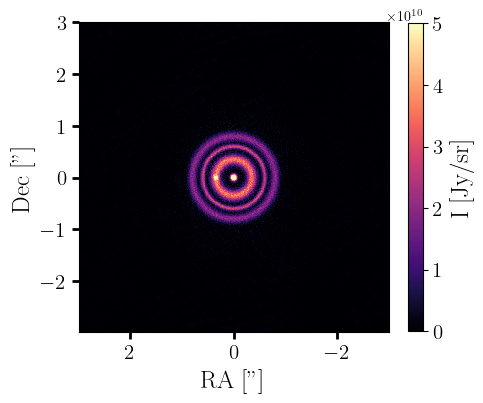

In [23]:
Plot_.intensity(gamma=1, zoom=1, vmax = 5e10, title="", fig_size=5, 
tick_label_size = 15, label_size = 18, title_size = 18)

## Comparing with the ground thruth

In [24]:
N = frank2d.Nx
dx = frank2d.dx # arcsec
dxy = dx/rad_to_arcsec
type_ ="Blob"
amp_core_ajustado = 0.00025 
amp_rings_ajustado = [0.000086, 0.000070, 0.000050] 
amp_asym_ajustado = [0.65, 0, 0]

reference_image = create_disk_image_blob_jy_per_pixel(
    N=N,                         # Image size (N x N pixels)
    pixel_scale_arcsec=dx,       # Pixel scale (0.01 arcsec = 10 mas)
    sigma_core=0.04,               # Gaussian core width (arcsec)
    R_rings=[0.35, 0.6, 0.8],       # Radii of the rings/blobs (arcsec)
    width_rings=[0.07, 0.03, 0.06], # Gaussian width of the rings (arcsec)
    width_blobs=[0.03, 0.03, 0.03], # Width of the localized blobs (arcsec)
    amp_core=amp_core_ajustado,    # Core amplitude (Jy/pixel)
    amp_rings=amp_rings_ajustado,  # Rings amplitude (Jy/pixel)
    amp_asym=amp_asym_ajustado,
    theta0=[np.pi, 0, 0],
    m_modes=[1, 0, 0])

In [25]:
N/2

321.0

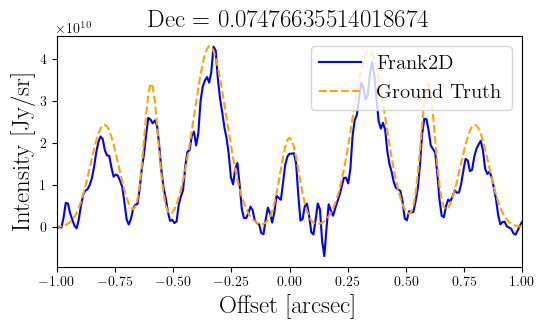

In [26]:
index_x = int(N/2 +8)

#frank2d
I_f2d = frank2d.intensity_model[index_x]
x = frank2d.x_grid[0]*rad_to_arcsec
y_i = frank2d.y_grid[index_x][0]*rad_to_arcsec

# Cálculo del área sólida (en sr)
sigma_sr =  (dx/rad_to_arcsec)**2
image_jy_per_sr = reference_image / sigma_sr
I_ground_truth = image_jy_per_sr[index_x]

plt.figure(figsize=(6,3))
plt.plot(x, I_f2d, label='Frank2D', color='blue')
plt.plot(x, I_ground_truth, label='Ground Truth', color='orange', linestyle='dashed')
plt.xlabel('Offset [arcsec]', size=18)
plt.ylabel('Intensity [Jy/sr]', size=18)
plt.title('Dec = ' + str(y_i), size=18)
plt.legend(fontsize=15)
plt.xlim(-rout, rout)
plt.show()

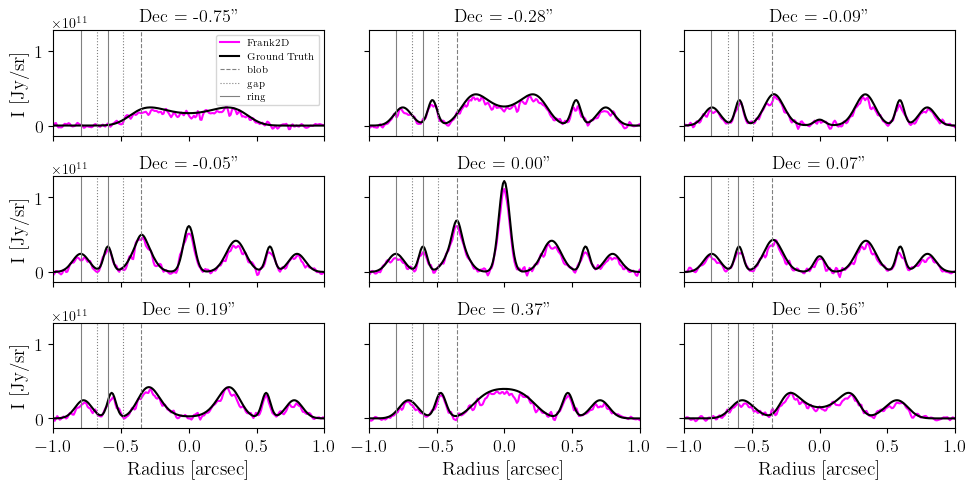

In [35]:
indices_seleccionados = [
    int(N/2 - 80),
    int(N/2 - 30),  
    int(N/2 - 10), 
    int(N/2 - 5), 
    int(N/2), 
    int(N/2 + 8),
    int(N/2 + 20),  # Nuevo índice 7
    int(N/2 + 40),  # Nuevo índice 8
    int(N/2 + 60)   # Nuevo índice 9
]


sigma_sr = (dx / rad_to_arcsec)**2
image_jy_per_sr = reference_image / sigma_sr

fig, axes = plt.subplots(3, 3, figsize=(10, 5), sharex=True, sharey=True)
axes = axes.flatten()

for i, ax in enumerate(axes):
    if i >= len(indices_seleccionados):
        ax.axis('off')
        continue
        
    idx = indices_seleccionados[i]

    I_f2d = frank2d.intensity_model[idx]
    x = frank2d.x_grid[0] * rad_to_arcsec
    y_i = frank2d.y_grid[idx][0] * rad_to_arcsec
    I_ground_truth = image_jy_per_sr[idx]

    ax.plot(x, I_f2d, label='Frank2D', color='magenta', ls='-')
    ax.plot(x, I_ground_truth, label='Ground Truth', color='black', linestyle='-')
    
    ax.set_title(f' Dec = {y_i:.2f}"', size=13)
    ax.set_xlim(-rout, rout)

    # increase fontsize ticks
    ax.tick_params(axis='both', which='both', labelsize=13)

    ax.axvline(-0.35, color='gray', linestyle='--', linewidth=0.8, label=r"blob")
    ax.axvline(-0.49, color='gray', linestyle='dotted', linewidth=0.8, label="gap")
    ax.axvline(-0.6, color='gray', linestyle='-', linewidth=0.8, label="ring")
    ax.axvline(-0.68, color='gray', linestyle='dotted', linewidth=0.8,)
    ax.axvline(-0.8, color='gray', linestyle='-', linewidth=0.8)

    
    if i % 3 == 0:
        ax.set_ylabel('I [Jy/sr]', size=14)
    
    if i >= 6:
        ax.set_xlabel('Radius [arcsec]', size=14)
    
    if i == 0:
        ax.legend(fontsize=7, loc='upper right')

#
plt.tight_layout()
plt.show()

In [28]:
import numpy as np
from sklearn.metrics import r2_score

def evaluate_cross_sections(model_image, truth_image, indices, axis_x_arcsec):
    """
    model_image: Array 2D completo de Frankenstein (Jy/sr)
    truth_image: Array 2D completo Ground Truth (Jy/sr)
    indices: Lista de índices (filas) seleccionados
    axis_x_arcsec: Array 1D con las coordenadas en arcsec (para calcular shift)
    """
    
    metrics = {
        "nrmse": [],
        "r2": [],
        "peak_err": [],
        "shift": []
    }
    
    print(f"{'Idx':<5} | {'NRMSE':<8} | {'R2':<8} | {'Peak Err':<10}")
    print("-" * 40)

    for idx in indices:
        # Extraer los cortes 1D
        cut_model = model_image[idx, :]
        cut_truth = truth_image[idx, :]
        
        # 1. NRMSE (Normalizado por la norma de la verdad de ese corte)
        norm_t = np.linalg.norm(cut_truth)
        diff = cut_model - cut_truth
        nrmse = np.linalg.norm(diff) / norm_t if norm_t > 0 else 0.0
        
        # 2. R2 Score (Fidelidad de la forma)
        r2 = r2_score(cut_truth, cut_model)
        
        # 3. Peak Error (Error relativo en el brillo máximo)
        peak_m = np.max(cut_model)
        peak_t = np.max(cut_truth)
        peak_err = (peak_m - peak_t) / peak_t if peak_t > 0 else 0.0
        
        # 4. Spatial Shift (Desplazamiento del pico)
        # Encuentra el índice donde está el máximo
        idx_peak_m = np.argmax(cut_model)
        idx_peak_t = np.argmax(cut_truth)
        shift = axis_x_arcsec[idx_peak_m] - axis_x_arcsec[idx_peak_t]

        metrics["nrmse"].append(nrmse)
        metrics["r2"].append(r2)
        metrics["peak_err"].append(peak_err)
        metrics["shift"].append(shift)
        
        print(f"{idx:<5} | {nrmse:.4f}   | {r2:.4f}   | {peak_err:.2%}")

    return metrics

# --- USO ---
# Asegúrate de pasar el eje X (RA) correcto para calcular el shift espacial
x_axis = frank2d.x_grid[0] * rad_to_arcsec 

stats = evaluate_cross_sections(
    frank2d.intensity_model, 
    image_jy_per_sr, 
    indices_seleccionados,
    x_axis
)

# Promedios para el texto
mean_nrmse = np.mean(stats["nrmse"])
std_nrmse = np.std(stats["nrmse"])
mean_r2 = np.mean(stats["r2"])

Idx   | NRMSE    | R2       | Peak Err  
----------------------------------------
241   | 0.2633   | 0.9168   | 4.37%
291   | 0.2023   | 0.9473   | -5.34%
311   | 0.2167   | 0.9419   | -6.28%
316   | 0.1986   | 0.9512   | -16.64%
321   | 0.1636   | 0.9686   | -8.76%
329   | 0.2354   | 0.9307   | -0.36%
341   | 0.2160   | 0.9413   | -1.69%
361   | 0.2164   | 0.9409   | -7.92%
381   | 0.2280   | 0.9351   | 0.72%
